In [ ]:
import psutil

ram = psutil.virtual_memory()
print(f"Total RAM: {ram.total / (1024**3):.2f} GB")
print(f"Available RAM: {ram.available / (1024**3):.2f} GB")

Total RAM: 172.95 GB
Available RAM: 169.92 GB


In [ ]:
# install requirements for v6 Tpu
!pip install opencv-python
!pip install tensorflow
!pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 147.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 176.9 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 kB 11.0 MB/s eta 0:00:00


In [ ]:
import zipfile
import os
import cv2
import numpy as np
import pandas as pd
import random
import tensorflow as tf
from skimage.metrics import structural_similarity as ssim
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.layers import Dense, Dropout, TimeDistributed, GlobalAveragePooling2D, GRU, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Nadam
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, f1_score

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [ ]:
# GLOBAL CONSTANTS
NUM_FRAMES = 40 #4
NUM_UNITS = 64
# MIN_FRAMES = 120
# max_frames = 120
IMAGE_HEIGHT, IMAGE_WIDTH = 224, 224
# SSIM_THRESHOLD = 0.80
# NUM_SHUFFLES = 6 #2 #6
# SEED = 42

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import numpy as np

# Load X_prep_segments_40.npy from Drive
#X = np.load('/content/drive/My Drive/Colab Notebooks_videoAnalytics/optimal_seg/X_prep_segments_40.npy') #X_prep_segments_40.npy'

# Load X_prep_segments_40.npy from Drive
X = np.load('/content/drive/My Drive/Colab Notebooks_videoAnalytics/optimal_seg/X_prep_segments_40.npy', mmap_mode='r')
# Print shape of X
print("Shape of X_prep:", X.shape)

# Load y_labels_segments_40.npy from Drive
y = np.load('/content/drive/My Drive/Colab Notebooks_videoAnalytics/optimal_seg/y_labels_segments_40.npy') #y_labels_segments_40.npy

# Print shape of y
print("Shape of y_labels:", y.shape)

Mounted at /content/drive
Shape of X_prep: (1351, 40, 224, 224, 3)
Shape of y_labels: (1351,)


In [ ]:
#shape of X
X.shape

(1351, 40, 224, 224, 3)

In [ ]:
#shape of y
y.shape

(1351,)

In [ ]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
# TRAIN-VALIDATION SPLIT
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

indices = np.arange(len(X))

train_idx, val_idx = train_test_split(
    indices, test_size=0.3, stratify=y, random_state=SEED
)

# Create train and validation sets using indexing (memory-efficient)
X_train = X[train_idx]
X_val = X[val_idx]
y_train = y[train_idx]
y_val = y[val_idx]

In [ ]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

X_train shape: (945, 40, 224, 224, 3)
X_val shape: (406, 40, 224, 224, 3)
y_train shape: (945,)
y_val shape: (406,)


In [ ]:
import tensorflow as tf

# Encoding
num_classes = 2  # Binary classification

# Convert integer labels to one-hot
y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes)
y_val_oh = tf.keras.utils.to_categorical(y_val, num_classes)

# Check shape
print("y_train one-hot shape:", y_train_oh.shape)
print("y_val one-hot shape:", y_val_oh.shape)

y_train one-hot shape: (945, 2)
y_val one-hot shape: (406, 2)


In [ ]:
# FEATURE EXTRACTION USING InceptionResNetV2
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = InceptionResNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)
)

219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [ ]:
# FEATURE EXTRACTION USING InceptionResNetV2
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = InceptionResNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 3)
)

# Apply global average pooling to reduce feature maps to a vector
global_avg_layer = GlobalAveragePooling2D()
feature_extractor = Model(inputs=base_model.input, outputs=global_avg_layer(base_model.output))

In [ ]:
# GRU-BASED MODEL DEFINITION
from tensorflow.keras.layers import Input, GRU, TimeDistributed, Dropout, Dense

# Define input layer for video sequences (NUM_FRAMES, HEIGHT, WIDTH, 3)
input_layer = Input(shape=(NUM_FRAMES, IMAGE_HEIGHT, IMAGE_WIDTH, 3))

# Extract frame-wise features using CNN (InceptionResNetV2) applied to each frame
inception = TimeDistributed(feature_extractor)(input_layer)

# First GRU layer with 1024 units, returning sequences
gru_1 = GRU(1024, return_sequences=True)(inception)
dropout_1 = Dropout(0.5)(gru_1)

# Second GRU layer with 512 units
gru_2 = GRU(512)(dropout_1)
dropout_2 = Dropout(0.5)(gru_2)

# SINGLE DENSE LAYER (64 UNITS)-Fully connected dense layer
dense_1 = Dense(64, activation="relu")(dropout_2)
dropout_3 = Dropout(0.5)(dense_1)

# Output layer for binary classification-one-hot  (2 neurons + sigmoid)
output_layer = Dense(num_classes, activation="sigmoid")(dropout_3)

# Define/Build the model
model = Model(inputs=input_layer, outputs=output_layer)

In [ ]:
# COMPILE MODEL
optimizer = Nadam(learning_rate=1e-4) #try1e-5
model.compile(
    loss="categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"])

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 40, 224, 224,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 40, 1536)       │    54,336,736 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 40, 1024)       │     7,870,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 512)            │     2,362,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,602,530 (246.44 MB)

 Trainable params: 64,541,986 (246.21 MB)

 Non-trainable params: 60,544 (236.50 KB)

In [ ]:
# EARLY STOPPING
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",    # Monitor validation loss
    patience=5,            # Stop if no improvement after 5 epochs
    restore_best_weights=True  # Restore best model weights
)

In [ ]:
# CALCULATE CLASS WEIGHTS
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
w0 = class_weights[0]
w1 = class_weights[1]

In [ ]:
# MODEL TRAINING
history = model.fit(
    X_train,
    y_train_oh,           # Use one-hot labels here
    epochs=10, #10, #10 #5, #10,
    batch_size=3,
    class_weight={0: w0, 1: w1},
    callbacks=[early_stopping],
    validation_data=(X_val, y_val_oh)  # Validation labels also one-hot
)

Epoch 1/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 2596s 5s/step - accuracy: 0.5915 - loss: 0.7156 - val_accuracy: 0.7857 - val_loss: 0.4962
Epoch 2/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1427s 5s/step - accuracy: 0.7238 - loss: 0.5982 - val_accuracy: 0.8177 - val_loss: 0.4617
Epoch 3/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1424s 5s/step - accuracy: 0.8074 - loss: 0.4720 - val_accuracy: 0.8522 - val_loss: 0.3613
Epoch 4/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1423s 5s/step - accuracy: 0.8444 - loss: 0.3730 - val_accuracy: 0.8399 - val_loss: 0.4206
Epoch 5/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1425s 5s/step - accuracy: 0.8286 - loss: 0.3934 - val_accuracy: 0.8596 - val_loss: 0.3121
Epoch 6/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1423s 5s/step - accuracy: 0.8677 - loss: 0.3019 - val_accuracy: 0.8596 - val_loss: 0.4420
Epoch 7/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1429s 5s/step - accuracy: 0.8974 - loss: 0.2451 - val_accuracy: 0.8818 - val_loss: 0.3173
Epoch 8/10
315/315 ━━━━━━━━━━━━━━━━━━━━ 1435s 5s/step - accuracy: 0.9090 - loss: 0.2236 - 

In [ ]:
# MODEL EVALUATION
loss, accuracy = model.evaluate(X_val, y_val_oh)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")


13/13 ━━━━━━━━━━━━━━━━━━━━ 109s 8s/step - accuracy: 0.8596 - loss: 0.3121
Validation Loss: 0.3121
Validation Accuracy: 0.8596


In [ ]:
# CONFUSION MATRIX
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predict probabilities
y_pred_prob = model.predict(X_val)

# Convert softmax probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_val_oh, axis=1)

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", classification_report(y_true, y_pred))

13/13 ━━━━━━━━━━━━━━━━━━━━ 393s 20s/step
Confusion Matrix:
 [[149  54]
 [  3 200]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.73      0.84       203
           1       0.79      0.99      0.88       203

    accuracy                           0.86       406
   macro avg       0.88      0.86      0.86       406
weighted avg       0.88      0.86      0.86       406



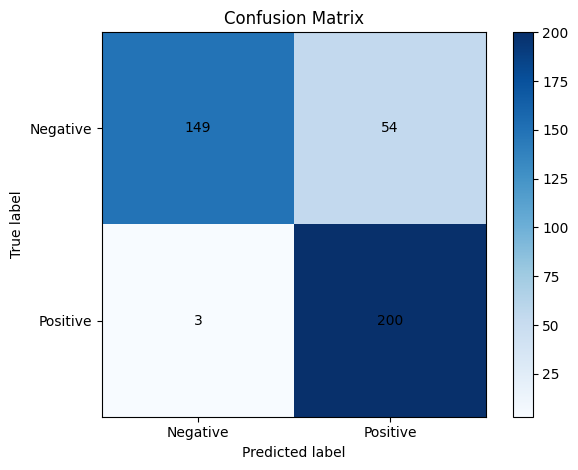

In [ ]:
# Plot confusion matrix
import matplotlib.pyplot as plt
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted label')
plt.ylabel('True label')
ticks = np.arange(2)
plt.xticks(ticks, ['Negative','Positive'])
plt.yticks(ticks, ['Negative','Positive'])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.tight_layout()
plt.savefig(f"confusion_matrix_single_64.png", dpi=300, bbox_inches='tight') #save figure
plt.show()

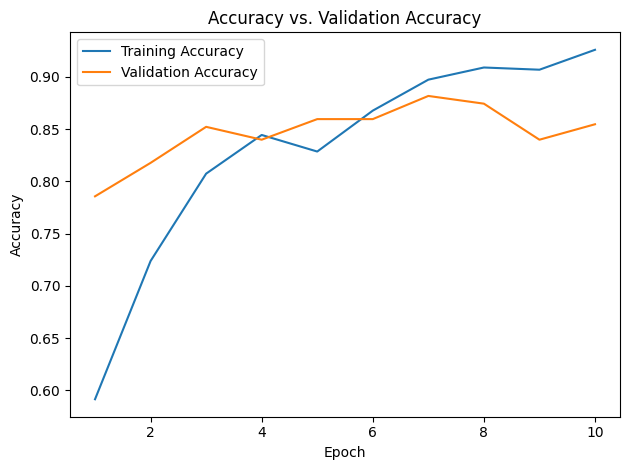

In [ ]:
# ACCURACY VS VALIDATION ACCURACY
accuracy     = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs       = range(1, len(accuracy) + 1)

plt.figure()
plt.plot(epochs, accuracy, label='Training Accuracy')
plt.plot(epochs, val_accuracy, label='Validation Accuracy')
plt.title('Accuracy vs. Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig(f"accuracy_plot_segments_single_incepResV2_64.png", dpi=300, bbox_inches='tight') ##save figure
plt.show()

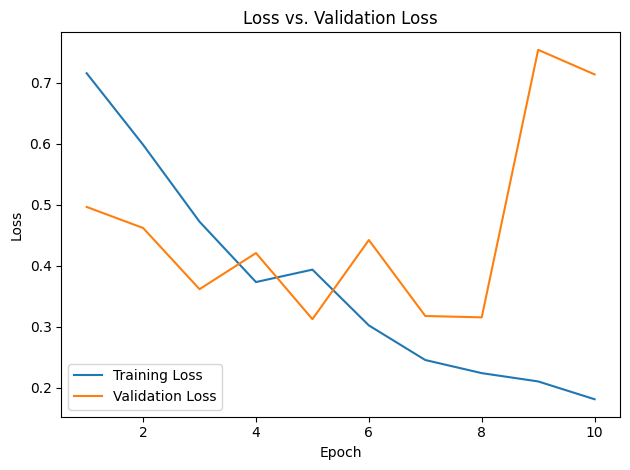

In [ ]:
# LOSS VS VALIDATION LOSS
loss      = history.history['loss']
val_loss  = history.history['val_loss']

plt.figure()
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Loss vs. Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig(f"loss_plot_single_64.png", dpi=300, bbox_inches='tight') ##save figure
plt.show()

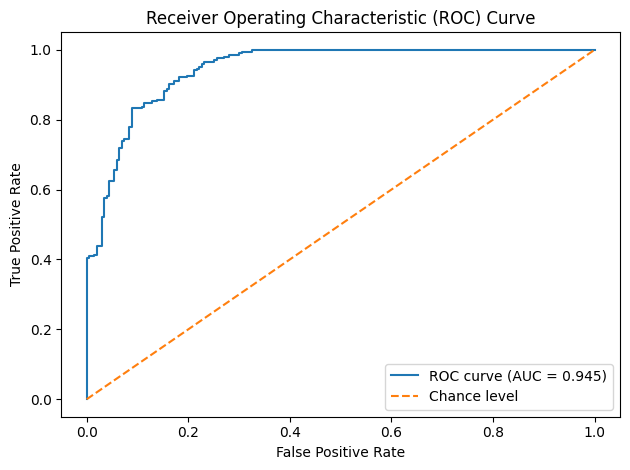

In [ ]:
# ROC CURVE
from sklearn.metrics import roc_curve, auc

# Compute ROC curve for positive class
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Chance level')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f"roc_curve_segments_single_incepResV2_64.png", dpi=300, bbox_inches='tight') ##save figure
plt.show()

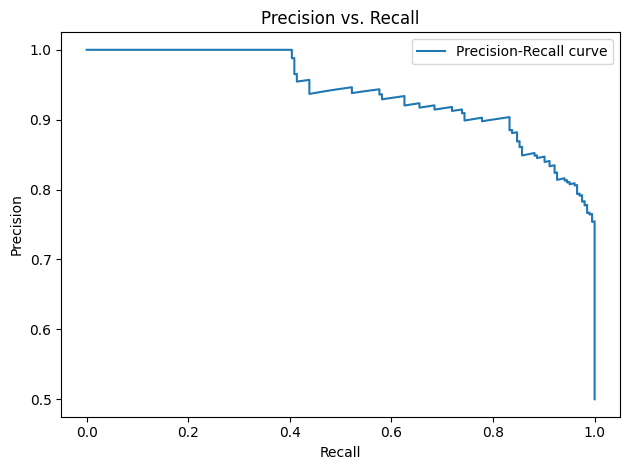

In [ ]:
# PRECISION-RECALL CURVE
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_true, y_pred_prob[:,1])

plt.figure()
plt.plot(recall, precision, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision vs. Recall')
plt.legend()
plt.tight_layout()
plt.savefig(f"precision_recall_curve__incepResV2single_64.png", dpi=300, bbox_inches='tight') ##save figure
plt.show()

In [ ]:
# EXPERIMENT RESULTS TABLE FOR CURRENT SEGMENT CONFIGURATION
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Calculate evaluation metrics
precision_val = precision_score(y_true, y_pred)
recall_val = recall_score(y_true, y_pred)
f1_val = f1_score(y_true, y_pred)
accuracy_val = accuracy_score(y_true, y_pred)

# Create results table
results_table = pd.DataFrame({
    "Units": [NUM_UNITS],
    "Accuracy": [accuracy_val],
    #"Validation Accuracy": [accuracy],
    #"Validation Loss": [loss],
    "Precision": [precision_val],
    "Recall": [recall_val],
    "F1 Score": [f1_val],
    "ROC AUC": [roc_auc]
})

# Display table
print(f"\nExperiment 1 Results Table: {NUM_UNITS} Units")
display(results_table)


Experiment 1 Results Table: 64 Units


,Units,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,64,0.859606,0.787402,0.985222,0.875274,0.945109


In [ ]:
# SAVE MODEL & WEIGHTS

print(f"\nBest Dense Units Based on ROC-AUC: {NUM_UNITS}")

model.save(f"InceptionResNetV2_model_{NUM_UNITS}.keras")
print("Model saved successfully!")

model.save(f"InceptionResNetV2_model_{NUM_UNITS}.h5")
print("Model saved successfully!")

model.save_weights(f"InceptionResNetV2_{NUM_UNITS}.weights.h5")
print("Model weights saved!")


Best Dense Units Based on ROC-AUC: 64


Model saved successfully!
Model saved successfully!
Model weights saved!


In [ ]:
!cp /content/InceptionResNetV2_64.weights.h5 "/content/drive/MyDrive/Colab Notebooks_videoAnalytics/model_experiment_notebooks/InceptionResNetV2_Expts_v1/single_layer_v1/"

In [ ]:
!cp /content/InceptionResNetV2_model_64.h5 "/content/drive/MyDrive/Colab Notebooks_videoAnalytics/model_experiment_notebooks/InceptionResNetV2_Expts_v1/single_layer_v1/"

In [ ]:
!cp /content/InceptionResNetV2_model_64.keras "/content/drive/MyDrive/Colab Notebooks_videoAnalytics/model_experiment_notebooks/InceptionResNetV2_Expts_v1/single_layer_v1/"

In [ ]:
#cjheck contents in the folder containing weights
!ls "/content/drive/MyDrive/Colab Notebooks_videoAnalytics/model_experiment_notebooks/InceptionResNetV2_Expts_v1/single_layer_v1/"

'Expt1_single dense_1024 InceptionResNetV2.ipynb'
'Expt2_single dense_512_ InceptionResNetV2.ipynb.ipynb'
'Expt3_single dense_256_ InceptionResNetV2.ipynb.ipynb'
'Expt4_single dense_128_ InceptionResNetV2.ipynb.ipynb'
'Expt5_single dense_64_ InceptionResNetV2.ipynb.ipynb'
 InceptionResNetV2_128.weights.h5
 InceptionResNetV2_256.weights.h5
 InceptionResNetV2_64.weights.h5
 InceptionResNetV2_model_128.h5
 InceptionResNetV2_model_128.keras
 InceptionResNetV2_model_256.h5
 InceptionResNetV2_model_256.keras
 InceptionResNetV2_model_64.h5
 InceptionResNetV2_model_64.keras
 InceptionResNetV2_single_lyr_1024.h5
 InceptionResNetV2_single_lyr_1024.keras
 InceptionResNetV2_single_lyr_1024.weights.h5
 InceptionResNetV2_single_lyr_512.h5
 InceptionResNetV2_single_lyr_512.keras
 InceptionResNetV2_single_lyr_512.weights.h5
